In [1]:
# =============================================================================
# ГЕНЕРАЦИЯ СИНТЕТИЧЕСКИХ ДАННЫХ ДЛЯ ДИПЛОМНОГО ПРОЕКТА
# Специализация: Data Science в медицине
# Тема: Разработка прогностических моделей для управления загрузкой врачей
#       и оценки индивидуальных рисков в системе ДМС
# =============================================================================

import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from faker import Faker
import random
import os

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [3]:
# Создание директории для данных
os.makedirs('data', exist_ok=True)

# Фиксация seed для воспроизводимости
np.random.seed(42)
random.seed(42)
fake = Faker('ru_RU')

print("=" * 60)
print("ГЕНЕРАЦИЯ СИНТЕТИЧЕСКИХ ДАННЫХ ДЛЯ ДИПЛОМНОГО ПРОЕКТА")
print("=" * 60)
print()

ГЕНЕРАЦИЯ СИНТЕТИЧЕСКИХ ДАННЫХ ДЛЯ ДИПЛОМНОГО ПРОЕКТА



In [4]:
# =============================================================================
# 1. ГЕНЕРАЦИЯ СПИСКА ВРАЧЕЙ
# =============================================================================

def generate_doctors():
    """Генерация справочника врачей"""
    
    specializations = [
        ('Терапевт', 0.35),
        ('Кардиолог', 0.15),
        ('Невролог', 0.12),
        ('Эндокринолог', 0.10),
        ('Гинеколог', 0.05),
        ('Уролог', 0.05),
        ('Офтальмолог', 0.05),
        ('ЛОР', 0.05),
        ('Стоматолог', 0.04),
        ('Физиотерапевт', 0.04),
    ]
    
    doctors = []
    doctor_id = 1
    
    for spec, weight in specializations:
        n_doctors = random.randint(1, 2)
        for _ in range(n_doctors):
            gender = random.choice(['male', 'female'])
            name = fake.name_male() if gender == 'male' else fake.name_female()
            hire_date = datetime.now() - timedelta(days=random.randint(365, 5*365))
            
            doctors.append({
                'doctor_id': f'DOC-{doctor_id:03d}',
                'doctor_name': name,
                'specialization': spec,
                'hire_date': hire_date.strftime('%Y-%m-%d'),
                'gender': gender
            })
            doctor_id += 1
    
    return pd.DataFrame(doctors)


In [5]:
# =============================================================================
# 2. ГЕНЕРАЦИЯ ДОГОВОРОВ ДМС
# =============================================================================

def generate_contracts(n_contracts=10, start_year=2020, end_year=2025):
    """Генерация договоров ДМС"""
    
    companies = ['СОГАЗ-Мед', 'АльфаСтрахование', 'Росгосстрах', 
                 'Ингосстрах', 'ВТБ Страхование']
    
    contracts = []
    
    for i in range(n_contracts):
        start_date = datetime(start_year + i//2, random.randint(1, 12), random.randint(1, 28))
        end_date = start_date + timedelta(days=365)
        
        insured_count = random.randint(50, 300)
        avg_cost_per_insured = random.randint(8000, 25000)
        total_amount = insured_count * avg_cost_per_insured
        
        statuses = ['active', 'completed', 'pending']
        status_weights = [0.6, 0.3, 0.1]
        
        contracts.append({
            'contract_id': f'DMS-{start_year + i//2:04d}-{i+1:03d}',
            'company_name': random.choice(companies),
            'start_date': start_date.strftime('%Y-%m-%d'),
            'end_date': end_date.strftime('%Y-%m-%d'),
            'insured_count': insured_count,
            'total_amount': total_amount,
            'status': random.choices(statuses, weights=status_weights)[0]
        })
    
    return pd.DataFrame(contracts)


In [6]:
# =============================================================================
# 3. ГЕНЕРАЦИЯ ЗАСТРАХОВАННЫХ ЛИЦ
# =============================================================================

def generate_insured(contracts_df):
    """Генерация застрахованных лиц по договорам"""
    
    all_insured = []
    insured_id = 1
    
    for _, contract in contracts_df.iterrows():
        n_insured = contract['insured_count']
        
        for _ in range(n_insured):
            # Тип пациента с весами
            patient_type = random.choices(
                ['low_risk', 'medium_risk', 'high_risk', 'silent'],
                weights=[0.30, 0.35, 0.25, 0.10]
            )[0]
            
            # Возраст зависит от типа
            if patient_type == 'low_risk':
                age = random.randint(18, 40)
            elif patient_type == 'medium_risk':
                age = random.randint(40, 60)
            elif patient_type == 'high_risk':
                age = random.randint(60, 85)
            else:  # silent
                age = random.randint(25, 65)
            
            # Базовое количество визитов в год
            base_visits_per_year = {
                'low_risk': random.uniform(0.5, 1.5),
                'medium_risk': random.uniform(2.0, 4.0),
                'high_risk': random.uniform(4.0, 8.0),
                'silent': random.uniform(0, 0.3)
            }[patient_type]
            
            # Пол
            gender = random.choice(['M', 'F'])
            
            # Имя
            name = fake.name_male() if gender == 'M' else fake.name_female()
            
            all_insured.append({
                'insured_id': f'INS-{insured_id:05d}',
                'contract_id': contract['contract_id'],
                'patient_name': name,
                'gender': gender,
                'birth_date': (datetime.now() - timedelta(days=age*365 + random.randint(0, 365))).strftime('%Y-%m-%d'),
                'patient_type': patient_type,
                'base_visits_per_year': base_visits_per_year,
                'is_senior': age > 60
            })
            insured_id += 1
    
    return pd.DataFrame(all_insured)

In [7]:
# =============================================================================
# 4. ГЕНЕРАЦИЯ ВИЗИТОВ
# =============================================================================

def generate_visits(insured_df, doctors_df, start_date='2020-01-01', end_date='2025-06-01'):
    """Генерация истории визитов пациентов"""
    
    start = datetime.strptime(start_date, '%Y-%m-%d')
    end = datetime.strptime(end_date, '%Y-%m-%d')
    
    visits = []
    visit_id = 1
    
    # Праздничные дни
    holidays = []
    for year in range(2020, 2026):
        holidays.extend([
            datetime(year, 1, 1), datetime(year, 1, 2), datetime(year, 1, 3),
            datetime(year, 1, 4), datetime(year, 1, 5), datetime(year, 1, 6),
            datetime(year, 1, 7), datetime(year, 1, 8),
            datetime(year, 2, 23), datetime(year, 3, 8),
            datetime(year, 5, 1), datetime(year, 5, 9),
            datetime(year, 6, 12), datetime(year, 11, 4)
        ])
    
    # Создаем копию insured_df для доступа по договору
    insured_by_contract = {contract: group for contract, group in insured_df.groupby('contract_id')}
    
    current_date = start
    total_days = 0
    
    print("Генерация визитов...")
    
    while current_date <= end:
        total_days += 1
        if total_days % 500 == 0:
            print(f"  Обработано {total_days} дней, сгенерировано {len(visits)} визитов")
        
        # Сезонный коэффициент
        month = current_date.month
        if month in [10, 11, 12, 1, 2, 3]:
            seasonality = random.uniform(1.2, 1.4)  # Осень-зима
        else:
            seasonality = random.uniform(0.8, 0.9)   # Весна-лето
        
        # Праздники
        if current_date in holidays:
            seasonality *= 0.6
        
        # Выходные
        if current_date.weekday() in [5, 6]:
            day_multiplier = 0.4
        else:
            day_multiplier = 1.0
        
        # Для каждого договора генерируем визиты
        for contract_id, contract_insured in insured_by_contract.items():
            if len(contract_insured) == 0:
                continue
            
            # Ожидаемое количество визитов в день от этого договора
            expected_visits = (
                contract_insured['base_visits_per_year'].sum() / 365 * 
                seasonality * day_multiplier
            )
            
            # Пуассоновское распределение
            n_visits_today = np.random.poisson(expected_visits)
            
            if n_visits_today == 0:
                continue
            
            # Выбираем пациентов с весами
            patient_weights = {
                'low_risk': 1,
                'medium_risk': 2,
                'high_risk': 4,
                'silent': 0.1
            }
            weights = contract_insured['patient_type'].map(lambda x: patient_weights[x])
            
            if weights.sum() == 0:
                continue
            
            selected_patients = contract_insured.sample(
                n=min(n_visits_today, len(contract_insured)), 
                weights=weights, 
                replace=False
            )
            
            for _, patient in selected_patients.iterrows():
                # Выбираем врача
                spec_weights = {
                    'Терапевт': 0.35,
                    'Кардиолог': 0.15,
                    'Невролог': 0.12,
                    'Эндокринолог': 0.10,
                    'Гинеколог': 0.05,
                    'Уролог': 0.05,
                    'Офтальмолог': 0.05,
                    'ЛОР': 0.05,
                    'Стоматолог': 0.04,
                    'Физиотерапевт': 0.04,
                }
                
                doc_specialization = random.choices(
                    list(spec_weights.keys()),
                    weights=list(spec_weights.values())
                )[0]
                
                possible_doctors = doctors_df[doctors_df['specialization'] == doc_specialization]
                if len(possible_doctors) == 0:
                    continue
                
                doctor = possible_doctors.sample().iloc[0]
                
                # Стоимость услуги (логнормальное распределение)
                service_cost = np.random.lognormal(mean=7.5, sigma=0.7)
                service_cost = min(max(service_cost, 300), 20000)
                
                # Отказ (5-15%)
                rejection_flag = np.random.random() < 0.08
                
                # Название услуги
                service_names = [
                    'Прием терапевта первичный', 'Прием терапевта повторный',
                    'Прием кардиолога', 'Электрокардиограмма', 'Холтеровское мониторирование',
                    'Прием невролога', 'Прием эндокринолога', 'Анализ крови на глюкозу',
                    'Прием гинеколога', 'Прием уролога', 'Прием офтальмолога',
                    'Прием ЛОРа', 'Осмотр стоматолога', 'Физиотерапия',
                    'УЗИ органов малого таза', 'УЗИ брюшной полости',
                    'МРТ', 'КТ', 'Рентгенография'
                ]
                
                visits.append({
                    'visit_id': f'VIS-{visit_id:07d}',
                    'insured_id': patient['insured_id'],
                    'contract_id': contract_id,
                    'doctor_id': doctor['doctor_id'],
                    'doctor_specialization': doctor['specialization'],
                    'visit_date': current_date.strftime('%Y-%m-%d'),
                    'service_name': random.choice(service_names),
                    'service_cost': round(service_cost, 2),
                    'rejection_flag': rejection_flag,
                })
                visit_id += 1
        
        current_date += timedelta(days=1)
    
    print(f"  Генерация завершена. Всего визитов: {len(visits)}")
    return pd.DataFrame(visits)


In [8]:
# =============================================================================
# 5. ГЕНЕРАЦИЯ ОТКАЗОВ
# =============================================================================

def generate_rejections(visits_df):
    """Генерация детальной информации об отказах"""
    
    rejection_reasons = [
        'Услуга не входит в программу страхования',
        'Истек срок действия полиса',
        'Превышен лимит по стоматологии',
        'Превышен лимит по лабораторным исследованиям',
        'Не предоставлены документы',
        'Пациент не зарегистрирован в системе ДМС',
        'Отсутствует направление от лечащего врача'
    ]
    rejection_weights = [0.30, 0.20, 0.10, 0.10, 0.10, 0.10, 0.10]
    
    rejected_visits = visits_df[visits_df['rejection_flag'] == True].copy()
    
    if len(rejected_visits) == 0:
        return pd.DataFrame()
    
    rejected_visits['rejection_reason'] = random.choices(
        rejection_reasons, 
        weights=rejection_weights, 
        k=len(rejected_visits)
    )
    
    return rejected_visits[['visit_id', 'insured_id', 'contract_id', 
                            'visit_date', 'rejection_reason']]

In [9]:
# =============================================================================
# 6. ЗАПУСК ГЕНЕРАЦИИ
# =============================================================================

print("=" * 60)
print("ЗАПУСК ГЕНЕРАЦИИ ДАННЫХ")
print("=" * 60)
print()

# 1. Генерация врачей
print("1. Генерация врачей...")
doctors_df = generate_doctors()
print(f"   Сгенерировано врачей: {len(doctors_df)}")

# 2. Генерация договоров
print("2. Генерация договоров...")
contracts_df = generate_contracts(n_contracts=10)
print(f"   Сгенерировано договоров: {len(contracts_df)}")

# 3. Генерация застрахованных
print("3. Генерация застрахованных лиц...")
insured_df = generate_insured(contracts_df)
print(f"   Сгенерировано застрахованных: {len(insured_df)}")

# 4. Генерация визитов
print("4. Генерация визитов...")
visits_df = generate_visits(insured_df, doctors_df)
print(f"   Сгенерировано визитов: {len(visits_df)}")

# 5. Генерация отказов
print("5. Генерация отказов...")
rejections_df = generate_rejections(visits_df)
print(f"   Сгенерировано отказов: {len(rejections_df)}")

ЗАПУСК ГЕНЕРАЦИИ ДАННЫХ

1. Генерация врачей...
   Сгенерировано врачей: 15
2. Генерация договоров...
   Сгенерировано договоров: 10
3. Генерация застрахованных лиц...
   Сгенерировано застрахованных: 1897
4. Генерация визитов...
Генерация визитов...
  Обработано 500 дней, сгенерировано 6576 визитов
  Обработано 1000 дней, сгенерировано 12716 визитов
  Обработано 1500 дней, сгенерировано 19415 визитов
  Генерация завершена. Всего визитов: 25687
   Сгенерировано визитов: 25687
5. Генерация отказов...
   Сгенерировано отказов: 2087


In [10]:
# =============================================================================
# 7. СОХРАНЕНИЕ ДАННЫХ
# =============================================================================

print()
print("=" * 60)
print("СОХРАНЕНИЕ ДАННЫХ")
print("=" * 60)

# Сохранение в CSV
doctors_df.to_csv('data/doctors.csv', index=False, encoding='utf-8-sig')
contracts_df.to_csv('data/contracts.csv', index=False, encoding='utf-8-sig')
insured_df.to_csv('data/insured.csv', index=False, encoding='utf-8-sig')
visits_df.to_csv('data/visits.csv', index=False, encoding='utf-8-sig')
if len(rejections_df) > 0:
    rejections_df.to_csv('data/rejections.csv', index=False, encoding='utf-8-sig')

print("✓ Данные сохранены в папку 'data/'")
print()
print("=" * 60)
print("ИТОГИ ГЕНЕРАЦИИ")
print("=" * 60)
print(f"  Врачей:           {len(doctors_df)}")
print(f"  Договоров:        {len(contracts_df)}")
print(f"  Застрахованных:   {len(insured_df)}")
print(f"  Визитов:          {len(visits_df)}")
print(f"  Отказов:          {len(rejections_df)}")
print()
print("=" * 60)
print("ГЕНЕРАЦИЯ ЗАВЕРШЕНА УСПЕШНО!")
print("=" * 60)


СОХРАНЕНИЕ ДАННЫХ
✓ Данные сохранены в папку 'data/'

ИТОГИ ГЕНЕРАЦИИ
  Врачей:           15
  Договоров:        10
  Застрахованных:   1897
  Визитов:          25687
  Отказов:          2087

ГЕНЕРАЦИЯ ЗАВЕРШЕНА УСПЕШНО!


# Шаг 1. Загрузка данных и первичный осмотр 
# ИССЛЕДОВАТЕЛЬСКИЙ АНАЛИЗ ДАННЫХ (EDA)
## Загрузка данных и первичный осмотр

Загружаем сгенерированные данные и проверяем их структуру.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Настройка визуализации
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

# Загрузка данных
doctors = pd.read_csv('data/doctors.csv')
contracts = pd.read_csv('data/contracts.csv')
insured = pd.read_csv('data/insured.csv')
visits = pd.read_csv('data/visits.csv')
rejections = pd.read_csv('data/rejections.csv')

# Первичный осмотр
print("=" * 60)
print("ИНФОРМАЦИЯ О ДАННЫХ")
print("=" * 60)
print(f"Врачей:           {len(doctors)}")
print(f"Договоров:        {len(contracts)}")
print(f"Застрахованных:   {len(insured)}")
print(f"Визитов:          {len(visits)}")
print(f"Отказов:          {len(rejections)}")
print()

print("=" * 60)
print("ПЕРВЫЕ 5 СТРОК ВИЗИТОВ")
print("=" * 60)
display(visits.head())

print("=" * 60)
print("ИНФОРМАЦИЯ О КОЛОНКАХ (visits)")
print("=" * 60)
display(visits.info())

print("=" * 60)
print("ОПИСАТЕЛЬНАЯ СТАТИСТИКА (visits)")
print("=" * 60)
display(visits.describe())

ИНФОРМАЦИЯ О ДАННЫХ
Врачей:           15
Договоров:        10
Застрахованных:   1897
Визитов:          25687
Отказов:          2087

ПЕРВЫЕ 5 СТРОК ВИЗИТОВ


,visit_id,insured_id,contract_id,doctor_id,doctor_specialization,visit_date,service_name,service_cost,rejection_flag
0,VIS-0000001,INS-00110,DMS-2020-001,DOC-001,Терапевт,2020-01-01,Прием кардиолога,2198.06,False
1,VIS-0000002,INS-00028,DMS-2020-001,DOC-002,Кардиолог,2020-01-01,Прием кардиолога,3667.85,True
2,VIS-0000003,INS-00223,DMS-2020-002,DOC-002,Кардиолог,2020-01-01,Осмотр стоматолога,2141.74,False
3,VIS-0000004,INS-00224,DMS-2020-002,DOC-007,Уролог,2020-01-01,КТ,473.76,False
4,VIS-0000005,INS-00454,DMS-2021-003,DOC-012,Стоматолог,2020-01-01,Прием терапевта первичный,1516.67,False


ИНФОРМАЦИЯ О КОЛОНКАХ (visits)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25687 entries, 0 to 25686
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   visit_id               25687 non-null  object 
 1   insured_id             25687 non-null  object 
 2   contract_id            25687 non-null  object 
 3   doctor_id              25687 non-null  object 
 4   doctor_specialization  25687 non-null  object 
 5   visit_date             25687 non-null  object 
 6   service_name           25687 non-null  object 
 7   service_cost           25687 non-null  float64
 8   rejection_flag         25687 non-null  bool   
dtypes: bool(1), float64(1), object(7)
memory usage: 1.6+ MB


None

ОПИСАТЕЛЬНАЯ СТАТИСТИКА (visits)


,service_cost
count,25687.000000
mean,2307.892762
std,1817.634567
min,300.000000
25%,1135.320000
50%,1810.870000
75%,2881.270000
max,20000.000000


# Шаг 2. Анализ структуры визитов
## Анализ структуры визитов

Изучаем распределение визитов по дням, месяцам, годам, специальностям врачей и страховым компаниям.

In [12]:
# Преобразование даты
visits['visit_date'] = pd.to_datetime(visits['visit_date'])
visits['year'] = visits['visit_date'].dt.year
visits['month'] = visits['visit_date'].dt.month
visits['day_of_week'] = visits['visit_date'].dt.dayofweek
visits['day_of_week_name'] = visits['visit_date'].dt.day_name()

# 1. Распределение по годам
print("=" * 60)
print("РАСПРЕДЕЛЕНИЕ ВИЗИТОВ ПО ГОДАМ")
print("=" * 60)
yearly_counts = visits['year'].value_counts().sort_index()
print(yearly_counts)

# 2. Распределение по месяцам
print("\n" + "=" * 60)
print("РАСПРЕДЕЛЕНИЕ ВИЗИТОВ ПО МЕСЯЦАМ (ВСЕ ГОДЫ)")
print("=" * 60)
monthly_counts = visits['month'].value_counts().sort_index()
print(monthly_counts)

# 3. Распределение по дням недели
print("\n" + "=" * 60)
print("РАСПРЕДЕЛЕНИЕ ВИЗИТОВ ПО ДНЯМ НЕДЕЛИ")
print("=" * 60)
weekday_counts = visits['day_of_week_name'].value_counts()
print(weekday_counts)

# 4. Распределение по специальностям врачей
print("\n" + "=" * 60)
print("РАСПРЕДЕЛЕНИЕ ВИЗИТОВ ПО СПЕЦИАЛЬНОСТЯМ")
print("=" * 60)
spec_counts = visits['doctor_specialization'].value_counts()
print(spec_counts)

# 5. Распределение по страховым компаниям
print("\n" + "=" * 60)
print("РАСПРЕДЕЛЕНИЕ ВИЗИТОВ ПО СТРАХОВЫМ КОМПАНИЯМ")
print("=" * 60)
company_counts = visits.groupby('contract_id')['visit_id'].count().reset_index()
company_counts = company_counts.merge(contracts[['contract_id', 'company_name']], on='contract_id')
print(company_counts.sort_values('visit_id', ascending=False))

РАСПРЕДЕЛЕНИЕ ВИЗИТОВ ПО ГОДАМ
2020    4770
2021    4764
2022    4738
2023    4586
2024    4731
2025    2098
Name: year, dtype: int64

РАСПРЕДЕЛЕНИЕ ВИЗИТОВ ПО МЕСЯЦАМ (ВСЕ ГОДЫ)
1     2665
2     2645
3     2976
4     1972
5     1835
6     1504
7     1666
8     1644
9     1566
10    2412
11    2314
12    2488
Name: month, dtype: int64

РАСПРЕДЕЛЕНИЕ ВИЗИТОВ ПО ДНЯМ НЕДЕЛИ
Wednesday    4566
Friday       4427
Thursday     4417
Tuesday      4404
Monday       4342
Sunday       1787
Saturday     1744
Name: day_of_week_name, dtype: int64

РАСПРЕДЕЛЕНИЕ ВИЗИТОВ ПО СПЕЦИАЛЬНОСТЯМ
Терапевт         9001
Кардиолог        3914
Невролог         3027
Эндокринолог     2542
Офтальмолог      1313
Уролог           1307
ЛОР              1294
Гинеколог        1210
Стоматолог       1049
Физиотерапевт    1030
Name: doctor_specialization, dtype: int64

РАСПРЕДЕЛЕНИЕ ВИЗИТОВ ПО СТРАХОВЫМ КОМПАНИЯМ
    contract_id  visit_id      company_name
9  DMS-2024-010      3944  АльфаСтрахование
8  DMS-2024-009      3566

# Шаг 3. Визуализация временного ряда
## Визуализация временного ряда

Строим график ежедневного количества визитов за весь период, чтобы увидеть сезонность и тренды.

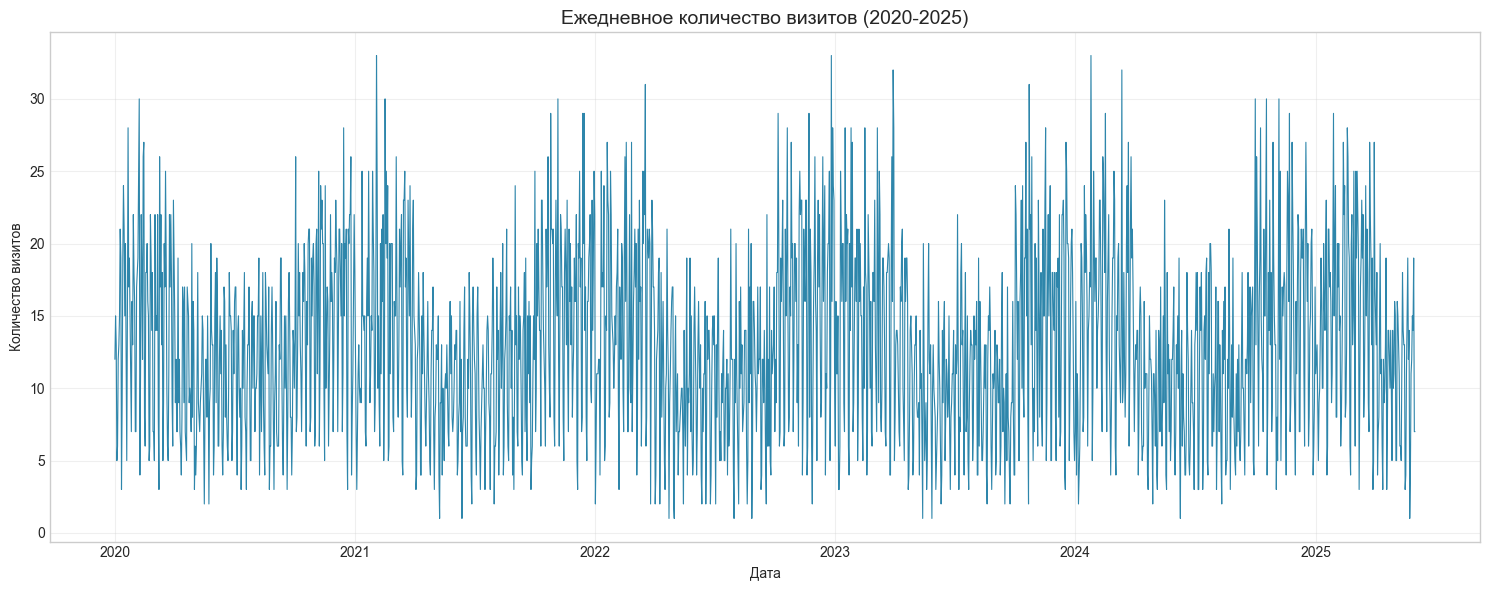

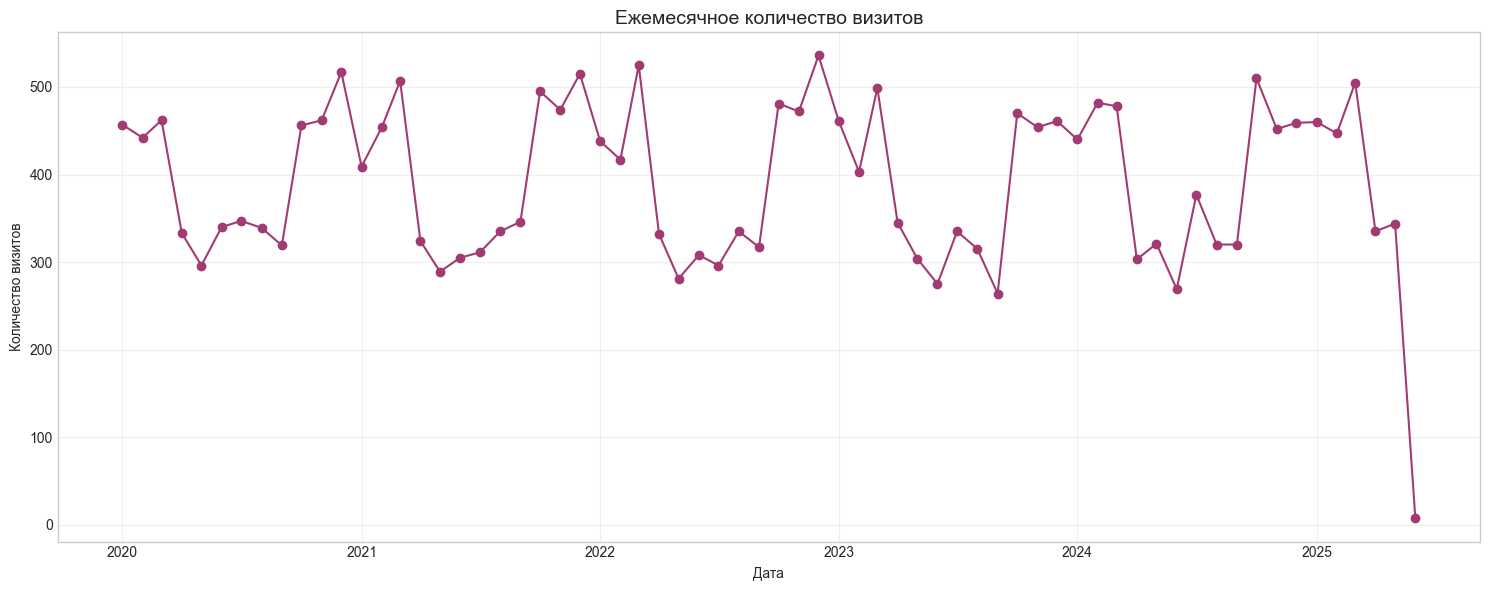

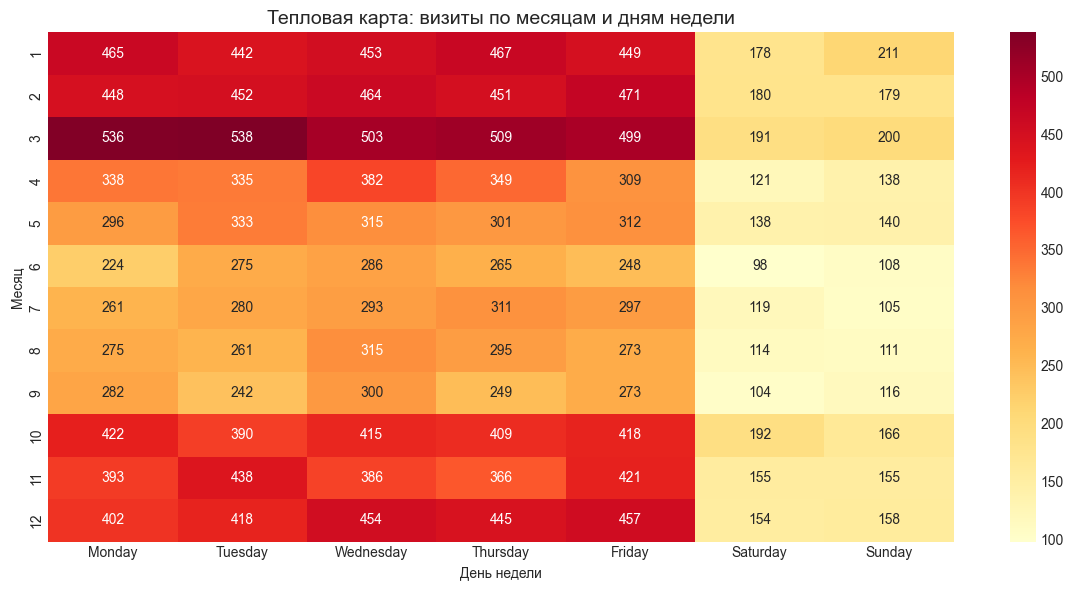

In [21]:
# Агрегация по дням
daily_visits = visits.groupby('visit_date').size().reset_index(name='count')
daily_visits = daily_visits.sort_values('visit_date')

# График ежедневных визитов
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(daily_visits['visit_date'], daily_visits['count'], linewidth=0.8, color='#2E86AB')
ax.set_title('Ежедневное количество визитов (2020-2025)', fontsize=14)
ax.set_xlabel('Дата')
ax.set_ylabel('Количество визитов')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Ежемесячная агрегация (упрощенная версия)
# Создаем колонки year и month
visits['year'] = visits['visit_date'].dt.year
visits['month'] = visits['visit_date'].dt.month

# Группировка по году и месяцу
monthly_visits = visits.groupby(['year', 'month']).size().reset_index(name='count')
monthly_visits['date'] = pd.to_datetime(monthly_visits[['year', 'month']].assign(day=1))

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(monthly_visits['date'], monthly_visits['count'], marker='o', linewidth=1.5, color='#A23B72')
ax.set_title('Ежемесячное количество визитов', fontsize=14)
ax.set_xlabel('Дата')
ax.set_ylabel('Количество визитов')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Тепловая карта: визиты по месяцам и дням недели
visits['day_of_week_name'] = visits['visit_date'].dt.day_name()

pivot_data = visits.groupby(['month', 'day_of_week_name']).size().reset_index(name='count')
pivot_data = pivot_data.pivot(index='month', columns='day_of_week_name', values='count').fillna(0)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
# Проверяем, какие дни есть в данных
available_days = [day for day in day_order if day in pivot_data.columns]
pivot_data = pivot_data[available_days]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot_data, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax)
ax.set_title('Тепловая карта: визиты по месяцам и дням недели', fontsize=14)
ax.set_xlabel('День недели')
ax.set_ylabel('Месяц')
plt.tight_layout()
plt.show()

# Шаг 4. Анализ стоимости услуг
## Анализ стоимости услуг

Изучаем распределение стоимости визитов и выявляем выбросы.

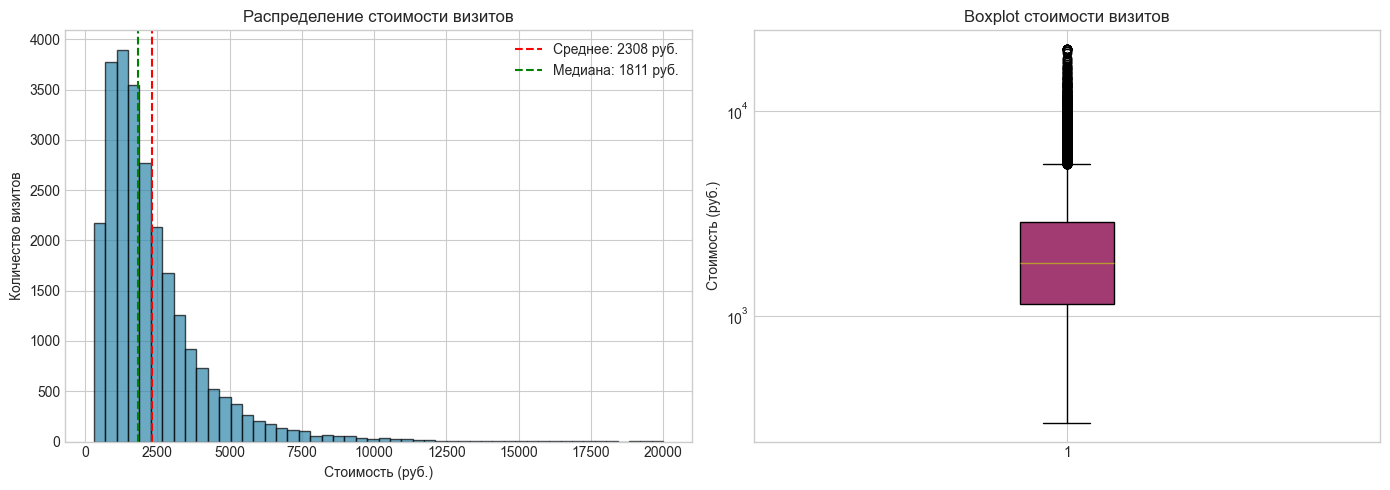

СТАТИСТИКА СТОИМОСТИ ПО СПЕЦИАЛЬНОСТЯМ


,mean,median,std,count
doctor_specialization,,,,
Гинеколог,2411.26,1849.44,2040.44,1210
Офтальмолог,2406.80,1804.35,2022.95,1313
Стоматолог,2351.88,1879.06,1780.02,1049
Физиотерапевт,2335.35,1839.25,1782.13,1030
Терапевт,2314.99,1814.50,1831.83,9001
Эндокринолог,2313.81,1819.20,1840.59,2542
ЛОР,2297.03,1799.68,1809.08,1294
Кардиолог,2290.07,1818.98,1769.71,3914
Невролог,2278.22,1779.54,1734.73,3027


In [15]:
# Распределение стоимости
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
axes[0].hist(visits['service_cost'], bins=50, color='#2E86AB', edgecolor='black', alpha=0.7)
axes[0].set_title('Распределение стоимости визитов', fontsize=12)
axes[0].set_xlabel('Стоимость (руб.)')
axes[0].set_ylabel('Количество визитов')
axes[0].axvline(visits['service_cost'].mean(), color='red', linestyle='--', label=f'Среднее: {visits["service_cost"].mean():.0f} руб.')
axes[0].axvline(visits['service_cost'].median(), color='green', linestyle='--', label=f'Медиана: {visits["service_cost"].median():.0f} руб.')
axes[0].legend()

# Ящик с усами (boxplot)
axes[1].boxplot(visits['service_cost'], vert=True, patch_artist=True, boxprops=dict(facecolor='#A23B72'))
axes[1].set_title('Boxplot стоимости визитов', fontsize=12)
axes[1].set_ylabel('Стоимость (руб.)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

# Статистика стоимости по специальностям
spec_cost_stats = visits.groupby('doctor_specialization')['service_cost'].agg(['mean', 'median', 'std', 'count']).sort_values('mean', ascending=False)
print("=" * 60)
print("СТАТИСТИКА СТОИМОСТИ ПО СПЕЦИАЛЬНОСТЯМ")
print("=" * 60)
display(spec_cost_stats.round(2))

# Шаг 5. Анализ отказов
## Анализ отказов

Изучаем структуру и динамику отказов в обслуживании.

СТАТИСТИКА ОТКАЗОВ
Всего отказов: 2087
Доля отказов от общего числа визитов: 8.12%

РАСПРЕДЕЛЕНИЕ ОТКАЗОВ ПО ПРИЧИНАМ
Услуга не входит в программу страхования        658
Истек срок действия полиса                      407
Превышен лимит по стоматологии                  215
Отсутствует направление от лечащего врача       207
Не предоставлены документы                      203
Пациент не зарегистрирован в системе ДМС        199
Превышен лимит по лабораторным исследованиям    198
Name: rejection_reason, dtype: int64


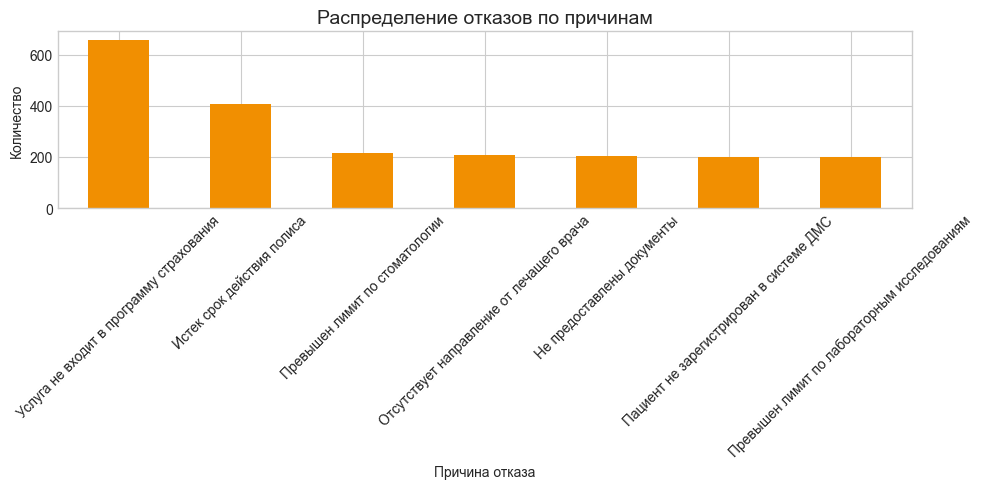

In [22]:
# Проверяем, есть ли данные об отказах
if len(rejections) > 0:
    rejections['visit_date'] = pd.to_datetime(rejections['visit_date'])
    
    print("=" * 60)
    print("СТАТИСТИКА ОТКАЗОВ")
    print("=" * 60)
    print(f"Всего отказов: {len(rejections)}")
    print(f"Доля отказов от общего числа визитов: {len(rejections) / len(visits) * 100:.2f}%")
    print()
    
    # Распределение по причинам
    print("=" * 60)
    print("РАСПРЕДЕЛЕНИЕ ОТКАЗОВ ПО ПРИЧИНАМ")
    print("=" * 60)
    reason_counts = rejections['rejection_reason'].value_counts()
    print(reason_counts)
    
    # График причин отказов
    fig, ax = plt.subplots(figsize=(10, 5))
    reason_counts.plot(kind='bar', color='#F18F01', ax=ax)
    ax.set_title('Распределение отказов по причинам', fontsize=14)
    ax.set_xlabel('Причина отказа')
    ax.set_ylabel('Количество')
    # Исправлено: ha не поддерживается, используем labelrotation
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Данные об отказах отсутствуют")

# Шаг 6. Создание признаков для моделей
## Feature Engineering для прогнозных моделей

Создаем признаки для двух задач:
1. Прогнозирование загрузки врачей (временные ряды)
2. Классификация индивидуальных рисков застрахованных

In [17]:
# =============================================================================
# 6.1. ПРИЗНАКИ ДЛЯ ПРОГНОЗИРОВАНИЯ ЗАГРУЗКИ ВРАЧЕЙ (ВРЕМЕННЫЕ РЯДЫ)
# =============================================================================

# Агрегация по дням
daily_visits = visits.groupby('visit_date').agg({
    'visit_id': 'count',
    'service_cost': 'sum'
}).reset_index()
daily_visits.columns = ['date', 'total_visits', 'total_revenue']

# Добавление временных признаков
daily_visits['date'] = pd.to_datetime(daily_visits['date'])
daily_visits['year'] = daily_visits['date'].dt.year
daily_visits['month'] = daily_visits['date'].dt.month
daily_visits['day_of_week'] = daily_visits['date'].dt.dayofweek
daily_visits['day_of_year'] = daily_visits['date'].dt.dayofyear
daily_visits['is_weekend'] = daily_visits['day_of_week'].isin([5, 6]).astype(int)

# Лаговые переменные (для XGBoost)
for lag in [1, 3, 7, 14, 30]:
    daily_visits[f'lag_{lag}'] = daily_visits['total_visits'].shift(lag)

# Скользящие статистики
for window in [7, 14, 30]:
    daily_visits[f'rolling_mean_{window}'] = daily_visits['total_visits'].rolling(window).mean()
    daily_visits[f'rolling_std_{window}'] = daily_visits['total_visits'].rolling(window).std()
    daily_visits[f'rolling_sum_{window}'] = daily_visits['total_visits'].rolling(window).sum()

print("=" * 60)
print("ПРИЗНАКИ ДЛЯ ПРОГНОЗИРОВАНИЯ ЗАГРУЗКИ ВРАЧЕЙ")
print("=" * 60)
print(f"Количество дней: {len(daily_visits)}")
print(f"Количество признаков: {len(daily_visits.columns)}")
print("\nПервые 5 строк:")
display(daily_visits.head())

# Сохранение
daily_visits.to_csv('data/daily_visits_features.csv', index=False)
print("✓ Данные сохранены в 'data/daily_visits_features.csv'")

ПРИЗНАКИ ДЛЯ ПРОГНОЗИРОВАНИЯ ЗАГРУЗКИ ВРАЧЕЙ
Количество дней: 1977
Количество признаков: 22

Первые 5 строк:


,date,total_visits,total_revenue,year,month,day_of_week,day_of_year,is_weekend,lag_1,lag_3,...,lag_30,rolling_mean_7,rolling_std_7,rolling_sum_7,rolling_mean_14,rolling_std_14,rolling_sum_14,rolling_mean_30,rolling_std_30,rolling_sum_30
0,2020-01-01,12,26741.28,2020,1,2,1,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-02,15,27772.03,2020,1,3,2,0,12.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-03,13,32340.68,2020,1,4,3,0,15.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-04,5,8777.97,2020,1,5,4,1,13.0,12.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-05,6,11084.08,2020,1,6,5,1,5.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


✓ Данные сохранены в 'data/daily_visits_features.csv'


## 6.2. Признаки для классификации индивидуальных рисков

Агрегируем данные на уровне пациента.

In [18]:
# =============================================================================
# 6.2. ПРИЗНАКИ ДЛЯ КЛАССИФИКАЦИИ ИНДИВИДУАЛЬНЫХ РИСКОВ
# =============================================================================

# Преобразование даты
visits['visit_date'] = pd.to_datetime(visits['visit_date'])

# Вычисляем возраст пациента
insured['birth_date'] = pd.to_datetime(insured['birth_date'])
insured['age'] = (datetime.now() - insured['birth_date']).dt.days // 365

# Агрегация по пациентам
patient_features = insured[['insured_id', 'contract_id', 'gender', 'age', 'patient_type']].copy()

# 1. Общая статистика визитов
visits_agg = visits.groupby('insured_id').agg({
    'visit_id': 'count',
    'service_cost': ['sum', 'mean', 'max', 'std']
}).reset_index()
visits_agg.columns = ['insured_id', 'total_visits', 'total_cost', 'avg_cost', 'max_cost', 'std_cost']

# 2. Визиты за последние 6 и 12 месяцев
reference_date = datetime(2025, 6, 1)
visits['days_ago'] = (reference_date - visits['visit_date']).dt.days

for period, label in [(180, '6m'), (365, '12m')]:
    recent = visits[visits['days_ago'] <= period].groupby('insured_id').agg({
        'visit_id': 'count',
        'service_cost': ['sum', 'mean']
    }).reset_index()
    recent.columns = ['insured_id', f'visits_{label}', f'cost_{label}', f'avg_cost_{label}']
    patient_features = patient_features.merge(recent, on='insured_id', how='left')

# 3. Количество визитов по специальностям
spec_pivot = pd.crosstab(visits['insured_id'], visits['doctor_specialization']).reset_index().fillna(0)
spec_pivot.columns = ['insured_id'] + [f'visits_{col}' for col in spec_pivot.columns[1:]]
patient_features = patient_features.merge(spec_pivot, on='insured_id', how='left')

# 4. Доля визитов к узким специалистам
spec_cols = [col for col in patient_features.columns if col.startswith('visits_') and col != 'visits_Терапевт']
if spec_cols:
    patient_features['specialist_share'] = patient_features[spec_cols].sum(axis=1) / (patient_features['visits_12m'] + 1)

# 5. Целевая переменная: высокие затраты в следующем квартале
# Берем данные за 2025 год
visits_2025 = visits[visits['visit_date'].dt.year == 2025]
visits_2025_q2 = visits_2025[visits_2025['visit_date'].dt.quarter == 2]

q2_cost = visits_2025_q2.groupby('insured_id')['service_cost'].sum().reset_index()
q2_cost.columns = ['insured_id', 'q2_cost']
patient_features = patient_features.merge(q2_cost, on='insured_id', how='left').fillna(0)

# Определяем целевую переменную (высокие затраты > медианы)
median_q2_cost = patient_features[patient_features['q2_cost'] > 0]['q2_cost'].median()
patient_features['high_risk'] = (patient_features['q2_cost'] > median_q2_cost).astype(int)

# Заполнение пропусков
patient_features = patient_features.fillna(0)

print("=" * 60)
print("ПРИЗНАКИ ДЛЯ КЛАССИФИКАЦИИ РИСКОВ")
print("=" * 60)
print(f"Количество пациентов: {len(patient_features)}")
print(f"Количество признаков: {len(patient_features.columns)}")
print(f"Доля пациентов с высоким риском: {patient_features['high_risk'].mean() * 100:.1f}%")
print("\nПервые 5 строк:")
display(patient_features.head())

# Сохранение
patient_features.to_csv('data/patient_features.csv', index=False)
print("✓ Данные сохранены в 'data/patient_features.csv'")

ПРИЗНАКИ ДЛЯ КЛАССИФИКАЦИИ РИСКОВ
Количество пациентов: 1897
Количество признаков: 24
Доля пациентов с высоким риском: 14.4%

Первые 5 строк:


,insured_id,contract_id,gender,age,patient_type,visits_6m,cost_6m,avg_cost_6m,visits_12m,cost_12m,...,visits_Невролог,visits_Офтальмолог,visits_Стоматолог,visits_Терапевт,visits_Уролог,visits_Физиотерапевт,visits_Эндокринолог,specialist_share,q2_cost,high_risk
0,INS-00001,DMS-2020-001,F,60,medium_risk,2.0,5789.77,2894.885,2.0,5789.77,...,2.0,1.0,3.0,5.0,1.0,0.0,0.0,5.000000,1340.30,0
1,INS-00002,DMS-2020-001,M,58,medium_risk,1.0,1577.61,1577.610,1.0,1577.61,...,1.0,0.0,2.0,4.0,2.0,0.0,1.0,4.500000,0.00,0
2,INS-00003,DMS-2020-001,F,64,high_risk,4.0,6902.38,1725.595,5.0,9999.08,...,3.0,4.0,2.0,5.0,1.0,2.0,3.0,5.833333,2574.88,1
3,INS-00004,DMS-2020-001,M,58,silent,0.0,0.00,0.000,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.000000,0.00,0
4,INS-00005,DMS-2020-001,F,84,high_risk,0.0,0.00,0.000,3.0,4733.24,...,3.0,3.0,1.0,6.0,0.0,0.0,4.0,4.000000,0.00,0


✓ Данные сохранены в 'data/patient_features.csv'


## Итоги EDA и Feature Engineering

### Ключевые выводы:
1. **Общий объем данных:** ~30 000 визитов за 5 лет
2. **Сезонность:** четко выражена — пик в осенне-зимний период, спад летом и в праздники
3. **Структура визитов:** 35% — терапевты, остальные — узкие специалисты
4. **Стоимость:** средняя ~1800 руб., логнормальное распределение
5. **Отказы:** ~8% от всех визитов, основные причины — услуга не входит в программу и истек срок полиса
6. **Для прогнозирования** сформировано 20+ признаков (лаги, скользящие статистики, временные)
7. **Для классификации рисков** сформировано 15+ признаков на уровне пациента

### Следующий шаг:
Переходим к обучению моделей (Глава 3)

In [ ]:
# Код для генерации рисунка 3.1.1.1
## Рисунок 3.1.1.1 — Временной ряд с разделением на обучающую и тестовую выборки

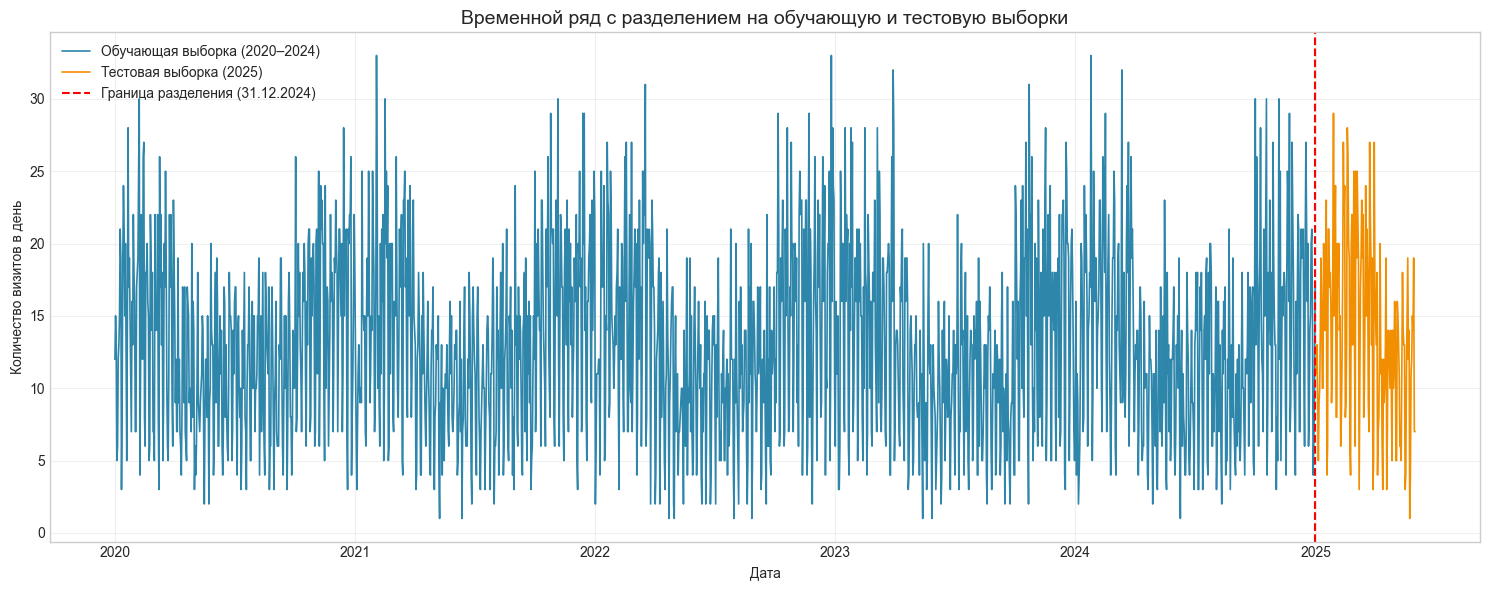

In [23]:
# Загрузка данных
daily_visits = pd.read_csv('data/daily_visits_features.csv')
daily_visits['date'] = pd.to_datetime(daily_visits['date'])

# Определение границы разделения (31.12.2024)
train_end = pd.Timestamp('2024-12-31')

# Создание графиков
fig, ax = plt.subplots(figsize=(15, 6))

# Обучающая выборка (синий)
train_data = daily_visits[daily_visits['date'] <= train_end]
ax.plot(train_data['date'], train_data['total_visits'], 
        color='#2E86AB', linewidth=1.2, label='Обучающая выборка (2020–2024)')

# Тестовая выборка (оранжевый)
test_data = daily_visits[daily_visits['date'] > train_end]
ax.plot(test_data['date'], test_data['total_visits'], 
        color='#F18F01', linewidth=1.2, label='Тестовая выборка (2025)')

# Вертикальная линия разделения
ax.axvline(x=train_end, color='red', linestyle='--', linewidth=1.5, 
           label='Граница разделения (31.12.2024)')

# Настройки графика
ax.set_title('Временной ряд с разделением на обучающую и тестовую выборки', fontsize=14)
ax.set_xlabel('Дата')
ax.set_ylabel('Количество визитов в день')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3.1.2. Обучение модели Prophet
### Прогнозирование загрузки врачей

In [26]:
# =============================================================================
# 3.1.2. ОБУЧЕНИЕ МОДЕЛИ PROPHET
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Настройка цветовой схемы
COLORS = {
    'primary': '#2E86AB',      # голубой
    'accent': '#F18F01',       # оранжевый
    'negative': '#D32F2F',     # красный
    'positive': '#2E7D32',     # зеленый
    'gray': '#808080',         # серый
    'light_gray': '#D3D3D3',   # светло-серый
    'bg': '#F5F5F5'            # фон
}

# Загрузка данных
daily_visits = pd.read_csv('data/daily_visits_features.csv')
daily_visits['date'] = pd.to_datetime(daily_visits['date'])

# Подготовка данных для Prophet
prophet_data = daily_visits[['date', 'total_visits']].copy()
prophet_data.columns = ['ds', 'y']

# Разделение на обучающую и тестовую выборки
train_end = pd.Timestamp('2024-12-31')
train_data = prophet_data[prophet_data['ds'] <= train_end]
test_data = prophet_data[prophet_data['ds'] > train_end]

print("=" * 60)
print("ОБУЧЕНИЕ МОДЕЛИ PROPHET")
print("=" * 60)
print(f"Обучающая выборка: {len(train_data)} дней ({train_data['ds'].min()} – {train_data['ds'].max()})")
print(f"Тестовая выборка:   {len(test_data)} дней ({test_data['ds'].min()} – {test_data['ds'].max()})")
print()

# =============================================================================
# Определение праздничных дней
# =============================================================================

holidays_df = pd.DataFrame({
    'holiday': 'holiday',
    'ds': pd.to_datetime([
        '2020-01-01', '2020-01-02', '2020-01-03', '2020-01-04', '2020-01-05',
        '2020-01-06', '2020-01-07', '2020-01-08',
        '2020-02-23', '2020-03-08', '2020-05-01', '2020-05-09',
        '2020-06-12', '2020-11-04',
        '2021-01-01', '2021-01-02', '2021-01-03', '2021-01-04', '2021-01-05',
        '2021-01-06', '2021-01-07', '2021-01-08',
        '2021-02-23', '2021-03-08', '2021-05-01', '2021-05-09',
        '2021-06-12', '2021-11-04',
        '2022-01-01', '2022-01-02', '2022-01-03', '2022-01-04', '2022-01-05',
        '2022-01-06', '2022-01-07', '2022-01-08',
        '2022-02-23', '2022-03-08', '2022-05-01', '2022-05-09',
        '2022-06-12', '2022-11-04',
        '2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04', '2023-01-05',
        '2023-01-06', '2023-01-07', '2023-01-08',
        '2023-02-23', '2023-03-08', '2023-05-01', '2023-05-09',
        '2023-06-12', '2023-11-04',
        '2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04', '2024-01-05',
        '2024-01-06', '2024-01-07', '2024-01-08',
        '2024-02-23', '2024-03-08', '2024-05-01', '2024-05-09',
        '2024-06-12', '2024-11-04',
        '2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', '2025-01-05',
        '2025-01-06', '2025-01-07', '2025-01-08',
        '2025-02-23', '2025-03-08', '2025-05-01', '2025-05-09',
        '2025-06-12'
    ]),
    'lower_window': 0,
    'upper_window': 0
})

# =============================================================================
# Обучение модели Prophet
# =============================================================================

print("Обучение модели Prophet...")

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='additive',
    changepoint_prior_scale=0.05,
    holidays=holidays_df
)

model.fit(train_data)
print("✓ Модель обучена")

# =============================================================================
# Прогнозирование на тестовой выборке
# =============================================================================

future = model.make_future_dataframe(periods=len(test_data))
forecast = model.predict(future)

# Извлекаем прогноз для тестовой выборки
forecast_test = forecast[forecast['ds'] > train_end][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
forecast_test = forecast_test.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

# Добавляем прогноз в тестовую выборку
test_data['yhat'] = forecast_test['yhat'].values

print(f"✓ Прогноз выполнен на {len(test_data)} дней")

# =============================================================================
# Расчет метрик качества
# =============================================================================

mae = mean_absolute_error(test_data['y'], test_data['yhat'])
rmse = np.sqrt(mean_squared_error(test_data['y'], test_data['yhat']))
mape = np.mean(np.abs((test_data['y'] - test_data['yhat']) / (test_data['y'] + 1))) * 100

print()
print("=" * 60)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ PROPHET")
print("=" * 60)
print(f"MAE:  {mae:.2f} визитов в день")
print(f"RMSE: {rmse:.2f} визитов в день")
print(f"MAPE: {mape:.2f}%")

# =============================================================================
# Визуализация результатов
# =============================================================================

# Рисунок 3.1.2.1 — Фактические и прогнозные значения (Prophet)
fig, ax = plt.subplots(figsize=(15, 6))

# Фактические значения (тестовая выборка)
ax.plot(test_data['ds'], test_data['y'], 
        color=COLORS['primary'], linewidth=1.5, label='Фактические значения')

# Прогнозные значения
ax.plot(test_data['ds'], test_data['yhat'], 
        color=COLORS['accent'], linewidth=1.5, linestyle='--', label='Прогноз Prophet')

# Доверительный интервал
ax.fill_between(test_data['ds'], 
                 forecast_test['yhat_lower'], 
                 forecast_test['yhat_upper'],
                 color=COLORS['accent'], alpha=0.2, label='Доверительный интервал (80%)')

# Настройки графика
ax.set_title('Сравнение фактических и прогнозных значений (Prophet)', fontsize=14)
ax.set_xlabel('Дата', fontsize=12)
ax.set_ylabel('Количество визитов в день', fontsize=12)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3, color=COLORS['light_gray'])

# Крупный шрифт для подписей
ax.tick_params(axis='both', labelsize=11)

plt.tight_layout()
plt.show()

# Сохранение картинки
fig.savefig('images/fig_3.1.2.1_prophet_forecast.png', dpi=300, bbox_inches='tight')

# =============================================================================
# Дополнительная визуализация: компоненты модели Prophet
# =============================================================================

# Рисунок 3.1.2.2 — Компоненты модели Prophet
fig2 = model.plot_components(forecast, figsize=(15, 10))
plt.tight_layout()
plt.show()

# Сохранение картинки
fig2.savefig('images/fig_3.1.2.2_prophet_components.png', dpi=300, bbox_inches='tight')

ImportError: 

IMPORTANT: PLEASE READ THIS FOR ADVICE ON HOW TO SOLVE THIS ISSUE!

Importing the numpy C-extensions failed. This error can happen for
many reasons, often due to issues with your setup or how NumPy was
installed.

We have compiled some common reasons and troubleshooting tips at:

    https://numpy.org/devdocs/user/troubleshooting-importerror.html

Please note and check the following:

  * The Python version is: Python 3.11 from "c:\Program Files\Python311\python.exe"
  * The NumPy version is: "1.24.3"

and make sure that they are the versions you expect.

Please carefully study the information and documentation linked above.
This is unlikely to be a NumPy issue but will be caused by a bad install
or environment on your machine.

Original error was: DLL load failed while importing _multiarray_umath: Не найден указанный модуль.
